In [1]:
#importing necessary files
import numpy as np
import math
import matplotlib.pyplot as plt
import multiprocess
import ulysses
from multiprocess import Pool
from itertools import repeat
import time
# from numpy.lib.function_base import meshgrid
from scipy.integrate import solve_ivp
from numba import njit
from NumbaQuadpack import quadpack_sig, dqags
import numba as nb

In [2]:
#Setting up the s channel integral for RHN
#Et integrand by multiplyinng A.39 and A.36
@nb.cfunc(quadpack_sig)
def Cs1etintegrand(et,data_):
    data=nb.carray(data_, (4,))
    el,z,fn,yn = data
    en   = math.sqrt(z * z + yn * yn)
    #Phase space factor from A.36
    lmbs = -(math.exp(-el-en) * (-1+fn+math.exp(en)*fn))/((1+math.exp(-el)) * (1+math.exp(-et)) * (1+math.exp(et-el-en)))
    alph = 4*yn*(el+en)
    beta = (en-yn)*(2*el+en-yn)/((en+yn)*(2*el+en+yn))
    #q integral result from A.39
    Is1  = (alph+z*z*math.log(beta))/(2*(el+en))
    return lmbs*Is1
Cs1etintegrand_ptr = Cs1etintegrand.address

#Solving Et integral from A.38
@nb.cfunc(quadpack_sig)
def ets1integral(el,data_):
    data = nb.carray(data_,(3,))
    z,fn,yn = data
    data1 = np.array([el,z,fn,yn],np.float64)
    en   = math.sqrt(z * z + yn * yn)
    etlowerlim = 1e-10
    ethigherlim = el+en
    integral,abserr,success_et = dqags(Cs1etintegrand_ptr,etlowerlim,ethigherlim,data1)
    return integral
ets1integral_ptr = ets1integral.address

#Solving El integral from A.38
@njit
def els1integral(z,fn,yn):
    data=np.array([z,fn[0],yn],np.float64)
    ellowerlim = yn
    elhigherlim = 300
    integral,abserr,success = dqags(ets1integral_ptr,ellowerlim,elhigherlim,data)  
    return integral

In [3]:
#Et integrand by multiplyinng A.41 and A.36
@nb.cfunc(quadpack_sig)
def Cs2etintegrand(et,data_):
    data=nb.carray(data_, (4,))
    el,z,fn,yn = data
    en   = math.sqrt(z * z + yn * yn)
    #Phase space factor from A.36
    lmbs = -(math.exp(-el-en) * (-1+fn+math.exp(en)*fn))/((1+math.exp(-el)) * (1+math.exp(-et)) * (1+math.exp(et-el-en)))
    alph = 4*el*(el+en)
    beta = (en*en-yn*yn)/((2*el+en)*(2*el+en)-yn*yn)
    #q integral result from A.41
    Is2  = (alph+z*z*math.log(beta))/(2*(el+en))
    return lmbs*Is2
Cs2etintegrand_ptr = Cs2etintegrand.address

#Solving Et integral from A.40
@nb.cfunc(quadpack_sig)
def ets2integral(el,data_):
    data = nb.carray(data_,(3,))
    z,fn,yn = data
    data1 = np.array([el,z,fn,yn],np.float64)
    en   = math.sqrt(z * z + yn * yn)
    etlowerlim = 1e-10
    ethigherlim = el+en
    integral,abserr,success_et = dqags(Cs2etintegrand_ptr,etlowerlim,ethigherlim,data1)  
    return integral
ets2integral_ptr = ets2integral.address

#Solving El integral from A.40
@njit
def els2integral(z,fn,yn):
    data=np.array([z,fn[0],yn],np.float64)
    ellowerlim = 1e-10
    elhigherlim = yn
    integral,abserr,success = dqags(ets2integral_ptr,ellowerlim,elhigherlim,data)   
    return integral

In [4]:
#Et integrand by multiplyinng A.43 and A.36
@nb.cfunc(quadpack_sig)
def Cs3etintegrand(et,data_):
    data=nb.carray(data_, (4,))
    el,z,fn,yn = data
    en   = math.sqrt(z * z + yn * yn)
    #Phase space factor from A.36
    lmbs = -(math.exp(-el-en) * (-1+fn+math.exp(en)*fn))/((1+math.exp(-el)) * (1+math.exp(-et)) * (1+math.exp(et-el-en)))
    alph = 2*(el+en)*(en-2*et+yn)
    beta = (et*(2*el+en-yn))/((el+en-et)*(en+yn))
    #q integral result from A.43
    Is3  = -(alph+z*z*math.log(beta))/(2*(el+en))
    return lmbs*Is3
Cs3etintegrand_ptr = Cs3etintegrand.address

#Solving Et integral from A.42
@nb.cfunc(quadpack_sig)
def ets3integral(el,data_):
    data = nb.carray(data_,(3,))
    z,fn,yn = data
    data1 = np.array([el,z,fn,yn],np.float64)
    en   = math.sqrt(z * z + yn * yn)
    etlowerlim = 1e-10
    ethigherlim = 0.5*(en+yn)
    integral,abserr,success_et = dqags(Cs3etintegrand_ptr,etlowerlim,ethigherlim,data1)
    return integral
ets3integral_ptr = ets3integral.address

#Solving El integral from A.42
@njit
def els3integral(z,fn,yn):
    data=np.array([z,fn[0],yn],np.float64)
    ellowerlim = yn
    elhigherlim = 300
    integral,abserr,success = dqags(ets3integral_ptr,ellowerlim,elhigherlim,data)  
    return integral


In [5]:
#Et integrand by multiplyinng A.45 and A.36
@nb.cfunc(quadpack_sig)
def Cs4etintegrand(et,data_):
    data=nb.carray(data_, (4,))
    el,z,fn,yn = data
    en   = math.sqrt(z * z + yn * yn)
    #Phase space factor from A.36
    lmbs = -(math.exp(-el-en) * (-1+fn+math.exp(en)*fn))/((1+math.exp(-el)) * (1+math.exp(-et)) * (1+math.exp(et-el-en)))
    alph = 2*(el+en)*(2*el+en-2*et-yn)
    beta = ((el+en-et)*(2*el+en-yn))/(et*(en+yn))
    #q integral result from A.45
    Is4  = (alph-z*z*math.log(beta))/(2*(el+en))
    return lmbs*Is4
Cs4etintegrand_ptr = Cs4etintegrand.address

#Solving Et integral from A.44
@nb.cfunc(quadpack_sig)
def ets4integral(el,data_):
    data = nb.carray(data_,(3,))
    z,fn,yn = data
    data1 = np.array([el,z,fn,yn],np.float64)  
    en   = math.sqrt(z * z + yn * yn)
    etlowerlim = 0.5*(2*el+en-yn)
    ethigherlim = el+en
    integral,abserr,success_et = dqags(Cs4etintegrand_ptr,etlowerlim,ethigherlim,data1)   
    return integral
ets4integral_ptr = ets4integral.address

#Solving El integral from A.44
@njit
def els4integral(z,fn,yn):
    data=np.array([z,fn[0],yn],np.float64)
    ellowerlim = yn
    elhigherlim = 300
    integral,abserr,success = dqags(ets4integral_ptr,ellowerlim,elhigherlim,data)         
    return integral

In [6]:
#Et integrand by multiplyinng A.47 and A.36
@nb.cfunc(quadpack_sig)
def Cs5etintegrand(et,data_):
    data=nb.carray(data_, (4,))
    el,z,fn,yn = data
    en   = math.sqrt(z * z + yn * yn)
    #Phase space factor from A.36
    lmbs = -(math.exp(-el-en) * (-1+fn+math.exp(en)*fn))/((1+math.exp(-el)) * (1+math.exp(-et)) * (1+math.exp(et-el-en)))
    alph = 2*(el+en)*(2*el+en-2*et-yn)
    beta = ((el+en-et)*(2*el+en-yn))/(et*(en+yn))
    #q integral result from A.47
    Is5  = -(alph-z*z*math.log(beta))/(2*(el+en))
    return lmbs*Is5
Cs5etintegrand_ptr = Cs5etintegrand.address

#Solving Et integral from A.46
@nb.cfunc(quadpack_sig)
def ets5integral(el,data_):
    data = nb.carray(data_,(3,))
    z,fn,yn = data
    data1 = np.array([el,z,fn,yn],np.float64)
    en   = math.sqrt(z * z + yn * yn)
    etlowerlim = 1e-10
    ethigherlim = 0.5*(2*el+en-yn)
    integral,abserr,success_et = dqags(Cs5etintegrand_ptr,etlowerlim,ethigherlim,data1)
    return integral
ets5integral_ptr = ets5integral.address

#Solving El integral from A.46
@njit
def els5integral(z,fn,yn):
    data=np.array([z,fn[0],yn],np.float64)
    ellowerlim = 1e-10
    elhigherlim = yn
    integral,abserr,success = dqags(ets5integral_ptr,ellowerlim,elhigherlim,data)          
    return integral

In [7]:

#Et integrand by multiplyinng A.49 and A.36
@nb.cfunc(quadpack_sig)
def Cs6etintegrand(et,data_):
    data=nb.carray(data_, (4,))
    el,z,fn,yn = data
    en   = math.sqrt(z * z + yn * yn)
    #Phase space factor from A.36
    lmbs = -(math.exp(-el-en) * (-1+fn+math.exp(en)*fn))/((1+math.exp(-el)) * (1+math.exp(-et)) * (1+math.exp(et-el-en)))
    alph = 2*(el+en)*(en-2*et+yn)
    beta = ((el+en-et)*(en+yn))/(et*(2*el+en-yn))
    #q integral result from A.49
    Is6  = (alph-z*z*math.log(beta))/(2*(el+en))
    return lmbs*Is6
Cs6etintegrand_ptr = Cs6etintegrand.address

#Solving Et integral from A.48
@nb.cfunc(quadpack_sig)
def ets6integral(el,data_):
    data = nb.carray(data_,(3,))
    z,fn,yn = data
    data1 = np.array([el,z,fn,yn],np.float64)
    en   = math.sqrt(z * z + yn * yn)
    etlowerlim = 0.5*(en+yn)
    ethigherlim = el+en
    integral,abserr,success_et = dqags(Cs6etintegrand_ptr,etlowerlim,ethigherlim,data1)
    return integral
ets6integral_ptr = ets6integral.address

#Solving El integral from A.48
@njit
def els6integral(z,fn,yn):
    data=np.array([z,fn[0],yn],np.float64)
    ellowerlim = 1e-10
    elhigherlim = yn
    integral,abserr,success = dqags(ets6integral_ptr,ellowerlim,elhigherlim,data)
    return integral

In [8]:
#Setting up the t channel integral for RHN
#Eq integrand by multiplyinng It1 (A.71) and A.69
@nb.cfunc(quadpack_sig)
def Ct1eqintegrand(eq,data_):
    data=nb.carray(data_, (4,))
    el,z,fn,yn = data
    en   = math.sqrt(z * z + yn * yn)
    # ah = 0.4/z
    ah = 1e-5
    #Phase space factor from A.69
    lmbt = -(math.exp(el+eq)*(-1+fn+math.exp(en)*fn))/((1+math.exp(el))*(1+math.exp(eq))*(math.exp(en+eq)+math.exp(el)))
    alph = 2*(en-el)*(2*eq-ah*z)
    beta = ((en+eq-el)*(ah*z))/(eq*(2*(en-el)+ah*z))
    #q integral result from It1 (A.71)
    It1  = (alph-z*z*math.log(beta))/(2*(en-el))
    return lmbt*It1
Ct1eqintegrand_ptr = Ct1eqintegrand.address

#Solving Eq integral from A.71
@nb.cfunc(quadpack_sig)
def eqt1integral(el,data_):
    data = nb.carray(data_,(3,))
    z,fn,yn = data
    data1 = np.array([el,z,fn,yn],np.float64)
    en   = math.sqrt(z * z + yn * yn)
    # ah = 0.4/z
    ah = 1e-5
    eqlowerlim = 0.5*ah*z
    eqhigherlim = 0.5*(2*el-en+yn)
    integral,abserr,success_eq = dqags(Ct1eqintegrand_ptr,eqlowerlim,eqhigherlim,data1)
    return integral
eqt1integral_ptr = eqt1integral.address

#Solving El integral from A.71
@njit
def elt1integral(z,fn,yn):
    data=np.array([z,fn[0],yn],np.float64)
    # ah = 0.4/z
    ah = 1e-5
    en   = math.sqrt(z * z + yn * yn)
    ellowerlim = 0.5*(en-yn+ah*z)
    elhigherlim = 0.5*(en+yn)
    integral,abserr,success = dqags(eqt1integral_ptr,ellowerlim,elhigherlim,data) 
    return integral


In [9]:

#Eq integrand by multiplyinng It2 (A.72) and A.69
@nb.cfunc(quadpack_sig)
def Ct2eqintegrand(eq,data_):
    data=nb.carray(data_, (4,))
    el,z,fn,yn = data
    en   = math.sqrt(z * z + yn * yn)
    # ah = 0.4/z
    ah = 1e-5
    #Phase space factor from A.69
    lmbt = -(math.exp(el+eq)*(-1+fn+math.exp(en)*fn))/((1+math.exp(el))*(1+math.exp(eq))*(math.exp(en+eq)+math.exp(el)))
    alph = 2*(en-el)*(2*el-en+yn-ah*z)
    beta = ((en+yn)*(-ah*z))/((en-2*el-yn)*(2*(en-el)+ah*z))
    #q integral result from It2 (A.72)
    It2  = (alph-z*z*math.log(beta))/(2*(en-el))
    return lmbt*It2
Ct2eqintegrand_ptr = Ct2eqintegrand.address

#Solving Eq integral from A.72
@nb.cfunc(quadpack_sig)
def eqt2integral(el,data_):
    data = nb.carray(data_,(3,))
    z,fn,yn = data
    data1 = np.array([el,z,fn,yn],np.float64)
    en   = math.sqrt(z * z + yn * yn)
    # ah = 0.4/z
    ah = 1e-5
    eqlowerlim = 0.5*(2*el-en+yn)
    eqhigherlim = 300
    integral,abserr,success_eq = dqags(Ct2eqintegrand_ptr,eqlowerlim,eqhigherlim,data1)
    return integral
eqt2integral_ptr = eqt2integral.address

#Solving El integral from A.72
@njit
def elt2integral(z,fn,yn):
    data=np.array([z,fn[0],yn],np.float64)
    # ah = 0.4/z
    ah = 1e-5
    en   = math.sqrt(z * z + yn * yn)
    ellowerlim = 0.5*(en-yn+ah*z)
    elhigherlim = 0.5*(en+yn)
    integral,abserr,success = dqags(eqt2integral_ptr,ellowerlim,elhigherlim,data) 
    return integral

In [10]:

#Eq integrand by multiplyinng It3 (A.73) and A.69
@nb.cfunc(quadpack_sig)
def Ct3eqintegrand(eq,data_):
    data=nb.carray(data_, (4,))
    el,z,fn,yn = data
    en   = math.sqrt(z * z + yn * yn)
    # ah = 0.4/z
    ah = 1e-5
    #Phase space factor from A.69
    lmbt = -(math.exp(el+eq)*(-1+fn+math.exp(en)*fn))/((1+math.exp(el))*(1+math.exp(eq))*(math.exp(en+eq)+math.exp(el)))
    alph = 2*(en-el)*(en+yn+2*(eq-el))
    beta = ((en-yn)*(-eq))/((en-2*el+yn)*(en+eq-el))
    #q integral result from It3 (A.73)
    It3  = (alph+z*z*math.log(beta))/(2*(en-el))
    return lmbt*It3
Ct3eqintegrand_ptr = Ct3eqintegrand.address

#Solving Eq integral from A.73
@nb.cfunc(quadpack_sig)
def eqt3integral(el,data_):
    data = nb.carray(data_,(3,))
    z,fn,yn = data
    data1 = np.array([el,z,fn,yn],np.float64)
    en   = math.sqrt(z * z + yn * yn)
    # ah = 0.4/z
    ah = 1e-5
    eqlowerlim = 0.5*(2*el-en-yn)
    eqhigherlim = 0.5*(2*el-en+yn)
    integral,abserr,success_eq = dqags(Ct3eqintegrand_ptr,eqlowerlim,eqhigherlim,data1)
    return integral
eqt3integral_ptr = eqt3integral.address

#Solving El integral from A.73
@njit
def elt3integral(z,fn,yn):
    data=np.array([z,fn[0],yn],np.float64)
    # ah = 0.4/z
    ah = 1e-5
    en   = math.sqrt(z * z + yn * yn)
    ellowerlim = 0.5*(en+yn)
    elhigherlim = 300
    integral,abserr,success = dqags(eqt3integral_ptr,ellowerlim,elhigherlim,data)         
    return integral

In [11]:

#Eq integrand by multiplyinng It4 (A.74) and A.69
@nb.cfunc(quadpack_sig)
def Ct4eqintegrand(eq,data_):
    data=nb.carray(data_, (4,))
    el,z,fn,yn = data
    en   = math.sqrt(z * z + yn * yn)
    # ah = 0.4/z
    ah = 1e-5
    #Phase space factor from A.69
    lmbt = -(math.exp(el+eq)*(-1+fn+math.exp(en)*fn))/((1+math.exp(el))*(1+math.exp(eq))*(math.exp(en+eq)+math.exp(el)))
    alph = 4*(en-el)*yn
    beta = ((en-yn)*(en-yn-2*el))/((en+yn)*(en+yn-2*el))\
    #q integral result from It4 (A.74)
    It4  = (alph+z*z*math.log(beta))/(2*(en-el))
    return lmbt*It4
Ct4eqintegrand_ptr = Ct4eqintegrand.address

#Solving Eq integral from A.74
@nb.cfunc(quadpack_sig)
def eqt4integral(el,data_):
    data = nb.carray(data_,(3,))
    z,fn,yn = data
    data1 = np.array([el,z,fn,yn],np.float64)
    en   = math.sqrt(z * z + yn * yn)
    # ah = 0.4/z
    ah = 1e-5
    eqlowerlim = 0.5*(2*el-en+yn)
    eqhigherlim = 300
    integral,abserr,success_eq = dqags(Ct4eqintegrand_ptr,eqlowerlim,eqhigherlim,data1)      
    return integral
eqt4integral_ptr = eqt4integral.address

#Solving El integral from A.74
@njit
def elt4integral(z,fn,yn):
    data=np.array([z,fn[0],yn],np.float64)
    # ah = 0.4/z
    ah = 1e-5
    en   = math.sqrt(z * z + yn * yn)
    ellowerlim = 0.5*(en+yn)
    elhigherlim = 300
    integral,abserr,success = dqags(eqt4integral_ptr,ellowerlim,elhigherlim,data)  
    return integral

In [12]:
Cs1_ = els1integral
Cs2_ = els2integral
Cs3_ = els3integral
Cs4_ = els4integral
Cs5_ = els5integral
Cs6_ = els6integral
Ct1_ = elt1integral
Ct2_ = elt2integral
Ct3_ = elt3integral
Ct4_ = elt4integral


In [13]:

'''Adding up all the parts of the Csintegral(A.38, A.40, A.42, A.44, A.46, A.48)
and multiplying them with the pre factor as well as a factor of 2 
(processes involving antiparticle)'''
def Csintegrand(z,fn,yn,K):
    ht = 0.95
    en = math.sqrt(z * z + yn * yn)
    integsum = Cs1_(z,fn,yn)+Cs2_(z,fn,yn)+Cs3_(z,fn,yn)+Cs4_(z,fn,yn)+Cs5_(z,fn,yn)+Cs6_(z,fn,yn)
    return 3*ht*ht*K/(4*np.pi*np.pi*en*yn)*integsum 

'''Adding up all the parts of the Csintegral(A.71, A.72, A.73, A.74)
and multiplying them with the pre factor as well as a factor of 4
(processes involving antiparticle and u channel)'''
def Ctintegrand(z,fn,yn,K):
    ht = 0.95
    en = math.sqrt(z * z + yn * yn)
    integsum = Ct1_(z,fn,yn)+Ct2_(z,fn,yn)+Ct3_(z,fn,yn)+Ct4_(z,fn,yn)
    Ctintrhs = 3*ht*ht*K/(2*np.pi*np.pi*en*yn)*integsum
    return Ctintrhs

'''RHS of the decay integral as in Case D4'''
def D4Nrhs( z, fN,yn,K):
    en = math.sqrt(z * z + yn * yn)
    gamma = (z * z * K)/(en * yn)
    fN = fN[0]
    delta = (fN - 1. + math.exp(en)*fN)/(math.exp(en) + 1.)
    
    A = (en-yn)/2
    B = (en+yn)/2
    alpha = 0.5*(math.exp(A)-math.exp(-A))
    beta = 0.5*(math.exp(B)-math.exp(-B))
    
    return gamma * delta * math.log(alpha / beta)

    
'''RHS of rhn evolution of Case S2'''
def S2rhs(z,fn,yn,K):
    S2ans= D4Nrhs(z,fn,yn,K)+Csintegrand(z,fn,yn,K)+Ctintegrand(z,fn,yn,K)
    return S2ans

In [14]:
'''Solving the differential equation for each yn to get fN(z,yN) for Case S2'''
def solveS2(yn, K, fN0 = [0], method="RK45", max_step=1/30):
    #z_span          =  [1e-2, math.floor(4*(-1*math.log10(K)+3))+1e-2]
    t0 = time.time()
    z_span          =  [1e-2, 16]
    nevalsz              =  2000
    zs          =  np.linspace(z_span[0], z_span[1], nevalsz).astype(np.float64)
    solS2_=solve_ivp(S2rhs, [zs[0], zs[-1]], fN0, \
            args=(yn,K,), method=method,max_step = max_step, rtol = 1e-7, atol = 1e-7, dense_output=True)

    try:
        a = solS2_.sol(zs)[0]
        # print("yay")
    except:
        print(yn,zs,solS2_.sol([0.1,1,2,4,5,8,10,12,15]))
        print(solS2_.sol(zs))
    return solS2_.sol(zs)[0]


In [15]:
def solveS2_store(yn,K):
    t0 = time.time()
    """Solving for Nn using multiprocessing 
    where cores is the no. of processors used"""
    with Pool(70) as p:
        fn_=np.float64(p.starmap(solveS2,zip(yn,repeat(K))))
    print(time.time()-t0)
    return fn_


In [18]:

def _compute_AB_single(args):
    """
    Worker function: computes A and B at a single (z, yn) point.

    Since S2rhs is linear in fN:
        S2rhs(z, [0], yn, K=1) = B(z, yn)
        S2rhs(z, [1], yn, K=1) = A(z, yn) + B(z, yn)

    The K=1 is intentional — K is just an overall prefactor so we factor
    it out completely.  At runtime: dfN/dz = K*(A*fN + B).
    """
    z, yn = args
    # print(z,yn)
    B = S2rhs(z, np.array([0.0]), yn, K=1.0)
    ApB = S2rhs(z, np.array([1.0]), yn, K=1.0)
    A = ApB - B
    return A, B

In [19]:

def compute_and_save_AB(z_grid, yn_vals, outfile="AB_grid_CaseS2.npz", cores=70):
    """
    OFFLINE step.  Evaluates the expensive nested integrals on a grid and
    stores the result.

    Parameters
    ----------
    z_grid   : 1D array, z values for the grid (e.g. 150–200 points, 0.01–16)
    yn_vals  : 1D array, momentum modes (same logspaced grid used elsewhere)
    outfile  : filename to save to
    cores    : number of parallel workers

    Output file contains:
        A_grid  shape (n_z, n_yn)
        B_grid  shape (n_z, n_yn)
        z_grid  1D
        yn_vals 1D
    """
    # Build flat list of (z, yn) pairs
    pairs = [(z, yn) for z in z_grid for yn in yn_vals]

    t0 = time.time()
    with Pool(cores) as p:
        results = p.map(_compute_AB_single, pairs)
    print(f"AB grid computed in {time.time()-t0:.1f}s")

    n_z  = len(z_grid)
    n_yn = len(yn_vals)

    A_flat, B_flat = zip(*results)
    A_grid = np.array(A_flat, dtype=np.float64).reshape(n_z, n_yn)
    B_grid = np.array(B_flat, dtype=np.float64).reshape(n_z, n_yn)

    np.savez(outfile, A_grid=A_grid, B_grid=B_grid,
             z_grid=z_grid, yn_vals=yn_vals)
    print(f"Saved to {outfile}  "
          f"(A_grid shape {A_grid.shape}, ~{A_grid.nbytes/1e6:.1f} MB)")


In [20]:
def load_AB(infile="AB_grid_CaseS2.npz"):
    """Load the precomputed AB grid.  Returns (A_grid, B_grid, z_grid, yn_vals)."""
    data = np.load(infile)
    return (data["A_grid"], data["B_grid"],
            data["z_grid"], data["yn_vals"])

In [21]:


def make_AB_eval(A_grid, B_grid, z_grid, yn_vals):
    """
    Build numba-compatible bilinear interpolators for A(z,yn) and B(z,yn).

    The interpolators are plain @njit functions that do a fast 2D lookup on
    the regular (z, log-yn) grid stored in A_grid / B_grid.

    Returns (eval_A, eval_B) — two @njit callables.
    """
    # Pre-compute the grid spacing for fast index arithmetic
    dlogz  = np.log(z_grid[1]) - np.log(z_grid[0])  # uniform in log(z)
    logz0  = np.log(z_grid[0])
    n_z    = len(z_grid)

    log_yn  = np.log10(yn_vals)
    dlog_yn = log_yn[1] - log_yn[0]          # uniform in log10(yn)
    log_yn0 = log_yn[0]
    n_yn    = len(yn_vals)

    # Make contiguous C-order copies so numba can stride them
    A = np.ascontiguousarray(A_grid)
    B = np.ascontiguousarray(B_grid)

    @njit
    def _bilinear(grid, z, yn):
        """Bilinear interpolation on the (z, log-yn) grid."""
        # z index
        log_z = math.log(z)
        iz = int((log_z - logz0) / dlogz)
        if iz < 0:
            iz = 0
        if iz >= n_z - 1:
            iz = n_z - 2
        tz = (log_z - logz0 - iz * dlogz) / dlogz

        # yn index (log-uniform)
        log_y = math.log10(yn)
        iy = int((log_y - log_yn0) / dlog_yn)
        if iy < 0:
            iy = 0
        if iy >= n_yn - 1:
            iy = n_yn - 2
        ty = (log_y - log_yn0 - iy * dlog_yn) / dlog_yn

        # Bilinear interpolation
        v00 = grid[iz,     iy    ]
        v10 = grid[iz + 1, iy    ]
        v01 = grid[iz,     iy + 1]
        v11 = grid[iz + 1, iy + 1]

        return ((1 - tz) * (1 - ty) * v00 +
                      tz * (1 - ty) * v10 +
                (1 - tz) *       ty * v01 +
                      tz *       ty * v11)

    @njit
    def eval_A(z, yn):
        return _bilinear(A, z, yn)

    @njit
    def eval_B(z, yn):
        return _bilinear(B, z, yn)

    return eval_A, eval_B

In [22]:
def _solve_fN_single_mode(args):
    yn, K, eval_A, eval_B, zs = args

    EN_min = math.sqrt(zs[0]**2 + yn**2)
    if EN_min > 50.0:
        return np.zeros(len(zs), dtype=np.float64)

    def rhs_g(z, g):
        en       = math.sqrt(z**2 + yn**2)
        fNeq     = 1.0 / (1.0 + math.exp(en))
        A        = eval_A(z, yn)
        B        = eval_B(z, yn)
        B_tilde  = B / fNeq
        dlnfNeq  = -(1.0 - fNeq) * (z / en)
        return [K * (A * g[0] + B_tilde) - g[0] * dlnfNeq]

    def jac_g(z, g):
        # d(rhs_g)/d(g) — trivial for linear ODE
        en      = math.sqrt(z**2 + yn**2)
        fNeq    = 1.0 / (1.0 + math.exp(en))
        A       = eval_A(z, yn)
        dlnfNeq = -(1.0 - fNeq) * (z / en)
        return [[K * A - dlnfNeq]]

    if K>3.0:
        sol = solve_ivp(rhs_g, [zs[0], zs[-1]], [0.0],
                    method="Radau", t_eval=zs,jac=jac_g,
                    rtol=1e-7, atol=1e-7)
    
    else:
        sol = solve_ivp(rhs_g, [zs[0], zs[-1]], [0.0],
                    method="RK45", t_eval=zs,
                    rtol=1e-7, atol=1e-7)

    if sol.success and sol.y.shape[1] == len(zs):
        # convert back: fN = g * fNeq
        en_vals   = np.sqrt(zs**2 + yn**2)
        fNeq_vals = 1.0 / (1.0 + np.exp(en_vals))
        return sol.y[0] * fNeq_vals

    # fallback
    en_vals = np.sqrt(zs**2 + yn**2)
    return 1.0 / (1.0 + np.exp(en_vals))

In [ ]:


def solve_fN_all_modes(yn_vals, K, zs, eval_A, eval_B, cores=70):

    args = [(yn, K, eval_A, eval_B, zs) for yn in yn_vals]

    t0 = time.time()
    with Pool(cores) as p:
        results = p.map(_solve_fN_single_mode, args)
    print(f"fN modes solved in {time.time()-t0:.1f}s for K={K}")

    return np.array(results, dtype=np.float64)   # shape (n_yn, n_z)



In [28]:
z_grid  = np.logspace(np.log10(0.01), np.log10(100), 250, dtype=np.float64)
yn_vals = np.logspace(-2., np.log10(105.), 400, dtype=np.float64)

compute_and_save_AB(
    z_grid  = z_grid,
    yn_vals = yn_vals,
    outfile = "AB_grid_CaseS2.npz",
    cores   = 70,
)
print("Done. AB grid ready for runtime use.")

AB grid computed in 177.3s
Saved to AB_grid_CaseS2.npz  (A_grid shape (250, 400), ~0.8 MB)
Done. AB grid ready for runtime use.


In [29]:
dum = load_AB("AB_grid_CaseS2.npz")

In [31]:
eval_A,eval_B = make_AB_eval(dum[0],dum[1],dum[2],dum[3])

In [32]:
# Define once, use everywhere at runtime
zs_runtime = np.logspace(np.log10(0.01), np.log10(50), 150, dtype=np.float64)

fn_store = solve_fN_all_modes(yn_vals, K=10, zs=zs_runtime, 
                               eval_A=eval_A, eval_B=eval_B)


fN modes solved in 10.3s for K=10


In [33]:
arg = np.argmin(abs(zs_runtime-0.4))

In [34]:
en = np.sqrt(zs_runtime[arg]*zs_runtime[arg]+yn_vals*yn_vals)
fneq = 1/(1+np.exp(en))

/tmp/ipykernel_2123155/2735530012.py:71: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


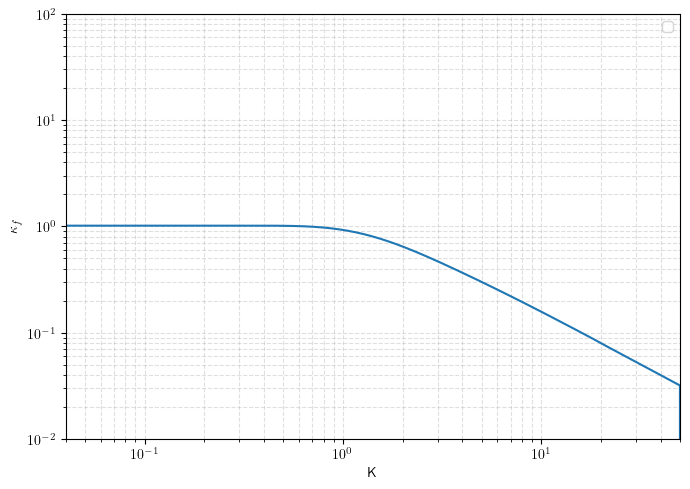

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(yn_vals,fn_store[:,arg]/fneq)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('K')
ax.set_ylabel(r'$\kappa_f$')
ax.set_xlim(0.04,50)
ax.set_ylim(0.01,100)
ax.legend()
ax.grid(True, which='both', ls='--', alpha=0.4)
plt.tight_layout()
plt.show()